In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/saltandpepper_Screen Shot 2018-06-12 at 8.53.54 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/Screen Shot 2018-06-12 at 9.27.26 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_45_Screen Shot 2018-06-12 at 8.58.13 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_75_Screen Shot 2018-06-12 at 8.47.41 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/rotated_by_75_Screen Shot 2018-06-12 at 8.56.30 PM.png
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana/saltandpepper_Screen Shot 2018-06-12 at 9.11.17 PM.png
/kaggle/input/datasets/sriramr/fruit

In [3]:
import os

print("Contents of /kaggle/input:")
for item in os.listdir("/kaggle/input"):
    print(" -", item)

Contents of /kaggle/input:
 - datasets


In [4]:
import os

print("\nSearching for the dataset...")

target = "fruits-fresh-and-rotten-for-classification"

for root, dirs, files in os.walk("/kaggle/input"):
    if target.lower() in root.lower():
        print("FOUND:", root)


Searching for the dataset...
FOUND: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification
FOUND: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset
FOUND: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset
FOUND: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test
FOUND: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenbanana
FOUND: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/freshoranges
FOUND: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenoranges
FOUND: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/freshbanana
FOUND: /kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenapples
FOUND: /kaggle/input/datas

In [5]:
import tensorflow as tf

DATASET_BASE = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset"

TRAIN_DIR = f"{DATASET_BASE}/train"
TEST_DIR = f"{DATASET_BASE}/test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:")
print(train_ds.class_names)

print("\nNumber of training batches:", len(train_ds))
print("Number of test batches:", len(test_ds))

Found 10901 files belonging to 6 classes.


2026-08-31 03:18:54.433934: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 2698 files belonging to 6 classes.
Classes:
['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']

Number of training batches: 341
Number of test batches: 85


In [6]:
# Re-create training and validation datasets
# 80% training + 20% validation

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    shuffle=False
)

print("Classes:", train_ds.class_names)
print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Test batches:", len(test_ds))

Found 10901 files belonging to 6 classes.
Using 8721 files for training.
Found 10901 files belonging to 6 classes.
Using 2180 files for validation.
Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Training batches: 273
Validation batches: 69
Test batches: 85


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Data pipeline ready.")

Data pipeline ready.


In [8]:
CLASS_NAMES = [
    "freshapples",
    "freshbanana",
    "freshoranges",
    "rottenapples",
    "rottenbanana",
    "rottenoranges"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)

Classes: ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']
Number of classes: 6


In [53]:
import tensorflow as tf
from tensorflow.keras import layers, models

new_model = tf.keras.Sequential([
    
    layers.Input(shape=(224, 224, 3)),
    
    # Normalize pixel values
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Classification
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(6, activation="softmax")
])

print("New CNN created successfully.")
model.summary()

New CNN created successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,509,204 (127.83 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,339,470 (85.22 MB)

In [54]:
new_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("New CNN compiled successfully.")

New CNN compiled successfully.


In [55]:
history_new = new_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3
)

Epoch 1/3
273/273 ━━━━━━━━━━━━━━━━━━━━ 530s 2s/step - accuracy: 0.6411 - loss: 0.9585 - val_accuracy: 0.7578 - val_loss: 0.6696
Epoch 2/3
273/273 ━━━━━━━━━━━━━━━━━━━━ 527s 2s/step - accuracy: 0.8297 - loss: 0.4890 - val_accuracy: 0.8317 - val_loss: 0.4498
Epoch 3/3
273/273 ━━━━━━━━━━━━━━━━━━━━ 529s 2s/step - accuracy: 0.8686 - loss: 0.3859 - val_accuracy: 0.8583 - val_loss: 0.3558


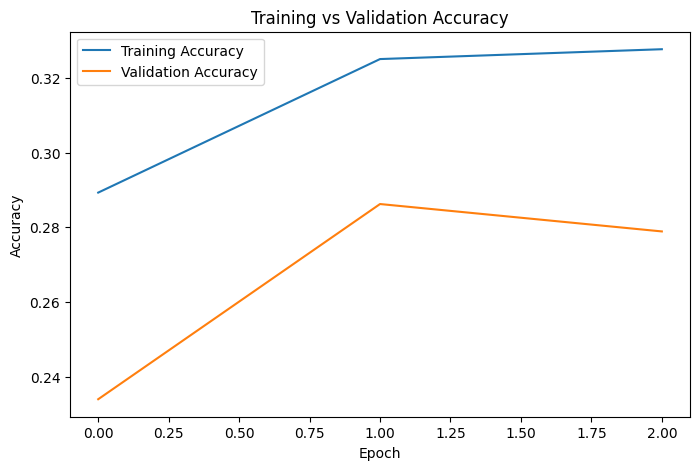

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

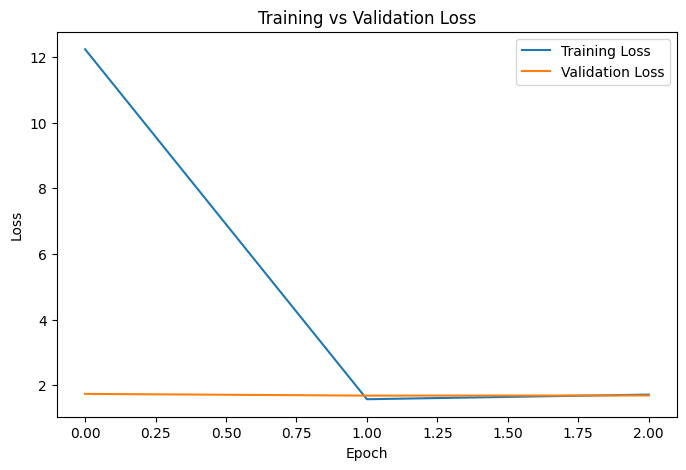

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [56]:
test_loss, test_accuracy = new_model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

85/85 ━━━━━━━━━━━━━━━━━━━━ 48s 556ms/step - accuracy: 0.9118 - loss: 0.2608
Test Loss: 0.2607964277267456
Test Accuracy: 0.9117864966392517


In [57]:
new_model.save("/kaggle/working/food_freshness_final.keras")

print("Final model saved successfully.")

Final model saved successfully.


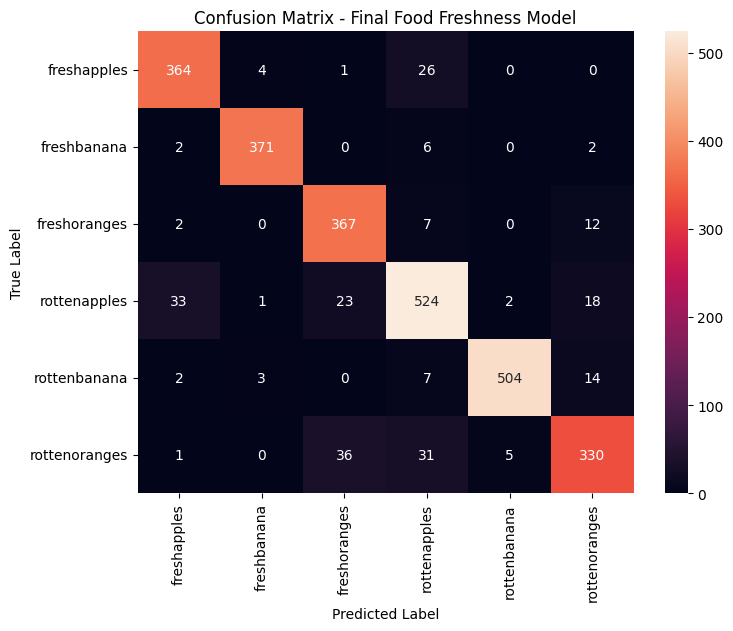

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = new_model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Final Food Freshness Model")
plt.show()

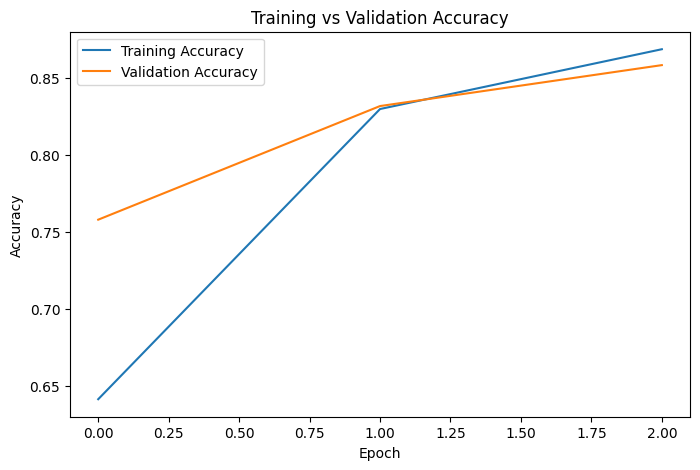

In [59]:
plt.figure(figsize=(8, 5))

plt.plot(history_new.history["accuracy"], label="Training Accuracy")
plt.plot(history_new.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

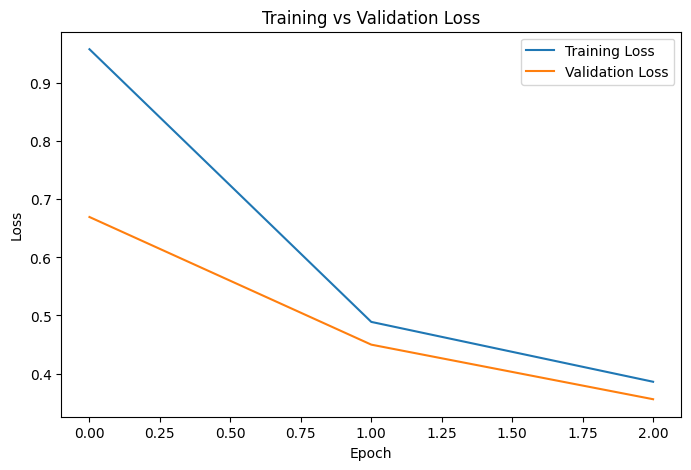

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(history_new.history["loss"], label="Training Loss")
plt.plot(history_new.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [60]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

  freshapples       0.90      0.92      0.91       395
  freshbanana       0.98      0.97      0.98       381
 freshoranges       0.86      0.95      0.90       388
 rottenapples       0.87      0.87      0.87       601
 rottenbanana       0.99      0.95      0.97       530
rottenoranges       0.88      0.82      0.85       403

     accuracy                           0.91      2698
    macro avg       0.91      0.91      0.91      2698
 weighted avg       0.91      0.91      0.91      2698



In [69]:
import random
import os

TEST_DIR = "/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test"

image_files = []

for root, dirs, files in os.walk(TEST_DIR):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(os.path.join(root, file))

image_path = random.choice(image_files)

print("Selected image:")
print(image_path)

Selected image:
/kaggle/input/datasets/sriramr/fruits-fresh-and-rotten-for-classification/dataset/dataset/test/rottenapples/vertical_flip_Screen Shot 2018-06-07 at 2.39.20 PM.png


In [74]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

def predict_fruit(image_path):

    # Load image
    img = load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert image to array
    img_array = img_to_array(img)

    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = new_model.predict(img_array, verbose=0)

    # Get predicted class
    predicted_index = np.argmax(prediction[0])
    predicted_class = class_names[predicted_index]

    # Confidence
    confidence = prediction[0][predicted_index] * 100

    return predicted_class, confidence

In [75]:
predicted_class, confidence = predict_fruit(image_path)

print("Actual Class:", os.path.basename(os.path.dirname(image_path)))
print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

Actual Class: rottenapples
Predicted Class: rottenapples
Confidence: 56.66 %


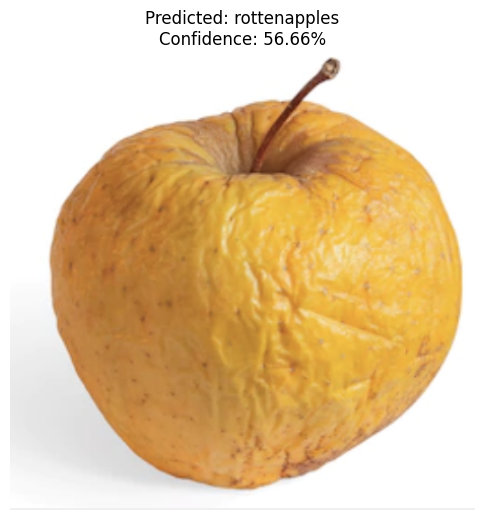

In [76]:
import matplotlib.pyplot as plt

img = load_img(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Predicted: {predicted_class}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.show()